# 📐 Linear Regression From Scratch
### Built on First Principles with NumPy

---

This notebook builds Linear Regression from the ground up — no `sklearn`, no `statsmodels`. Just math, NumPy, and intuition.

**What you'll learn:**
1. What a line really is (and why we want one)
2. The cost function — how we measure "wrong"
3. Gradient Descent — how we get "less wrong"
4. The Normal Equation — the closed-form solution
5. Multiple Linear Regression — many features, same idea
6. Diagnostics — checking your model's assumptions

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

# Styling
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#e0e0e0',
    'grid.color': '#333',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'monospace',
})

ACCENT = '#00e5ff'
ACCENT2 = '#ff6b6b'
ACCENT3 = '#69ff47'
GOLD = '#ffd166'

np.random.seed(42)
print('✅ Setup complete. Let\'s build from scratch.')

✅ Setup complete. Let's build from scratch.


---
## Part 1 — What Is a Line?

The equation of a line:

$$\hat{y} = w \cdot x + b$$

- $x$ — your input (feature)
- $\hat{y}$ — your prediction
- $w$ — **weight** (slope): how much $y$ changes per unit of $x$
- $b$ — **bias** (intercept): where the line crosses the y-axis

Our job: find the **best** $w$ and $b$ for a given dataset.

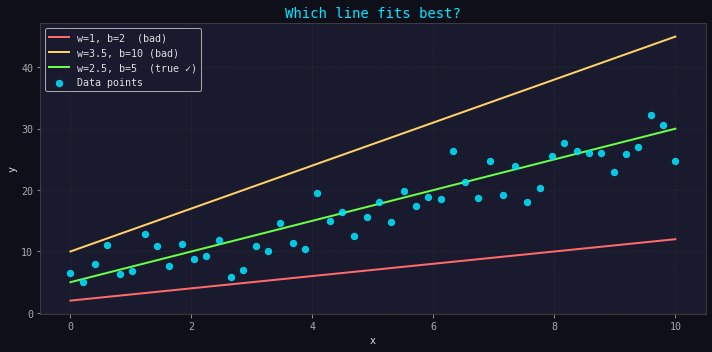

In [2]:
# ── Generate a toy dataset ──────────────────────────────────────────
n = 50
X = np.linspace(0, 10, n)
y = 2.5 * X + 5 + np.random.randn(n) * 3   # true: w=2.5, b=5

# ── Visualise several candidate lines ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(X, y, color=ACCENT, s=40, zorder=5, label='Data points', alpha=0.85)

candidates = [
    (1.0,  2.0, '#ff6b6b', 'w=1, b=2  (bad)'),
    (3.5, 10.0, '#ffd166', 'w=3.5, b=10 (bad)'),
    (2.5,  5.0, '#69ff47', 'w=2.5, b=5  (true ✓)'),
]
x_line = np.array([0, 10])
for w, b, col, lbl in candidates:
    ax.plot(x_line, w*x_line + b, color=col, lw=2, label=lbl)

ax.set_title('Which line fits best?', fontsize=14, color=ACCENT)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(loc='upper left')
ax.grid(True)
plt.tight_layout(); plt.show()

---
## Part 2 — The Cost Function: Measuring "Wrong"

For each point, our error (residual) is:
$$e_i = y_i - \hat{y}_i = y_i - (w x_i + b)$$

We square these and average — the **Mean Squared Error (MSE)**:

$$J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Why square?
- Positive and negative errors don't cancel
- Larger errors are penalised more heavily
- The function is smooth and differentiable (essential for gradient descent)

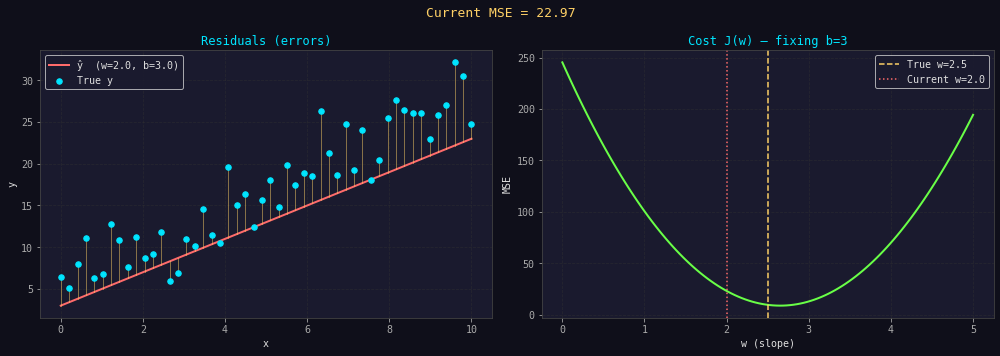

In [3]:
def mse(y_true, y_pred):
    """Mean Squared Error — the cost we minimise."""
    return np.mean((y_true - y_pred) ** 2)

def predict(X, w, b):
    return w * X + b

# ── Show residuals visually ──────────────────────────────────────────
w_demo, b_demo = 2.0, 3.0          # deliberately imperfect
y_hat = predict(X, w_demo, b_demo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: residuals as vertical lines
ax = axes[0]
ax.scatter(X, y, color=ACCENT, s=30, zorder=5, label='True y')
ax.plot(X, y_hat, color=ACCENT2, lw=2, label=f'ŷ  (w={w_demo}, b={b_demo})')
for xi, yi, yhi in zip(X, y, y_hat):
    ax.plot([xi, xi], [yi, yhi], color=GOLD, lw=0.8, alpha=0.6)
ax.set_title('Residuals (errors)', color=ACCENT)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(True)

# Right: MSE surface over w and b
ax2 = axes[1]
w_vals = np.linspace(0, 5, 120)
costs  = [mse(y, predict(X, w, b_demo)) for w in w_vals]
ax2.plot(w_vals, costs, color=ACCENT3, lw=2)
ax2.axvline(2.5, color=GOLD, linestyle='--', label='True w=2.5')
ax2.axvline(w_demo, color=ACCENT2, linestyle=':', label=f'Current w={w_demo}')
ax2.set_title('Cost J(w) — fixing b=3', color=ACCENT)
ax2.set_xlabel('w (slope)'); ax2.set_ylabel('MSE')
ax2.legend(); ax2.grid(True)

plt.suptitle(f'Current MSE = {mse(y, y_hat):.2f}', color=GOLD, fontsize=13)
plt.tight_layout(); plt.show()

---
## Part 3 — The 2D Cost Surface (Bowl Shape)

The cost function over **both** $w$ and $b$ forms a bowl — a convex surface with a single global minimum. That minimum is where our best $(w, b)$ lives.

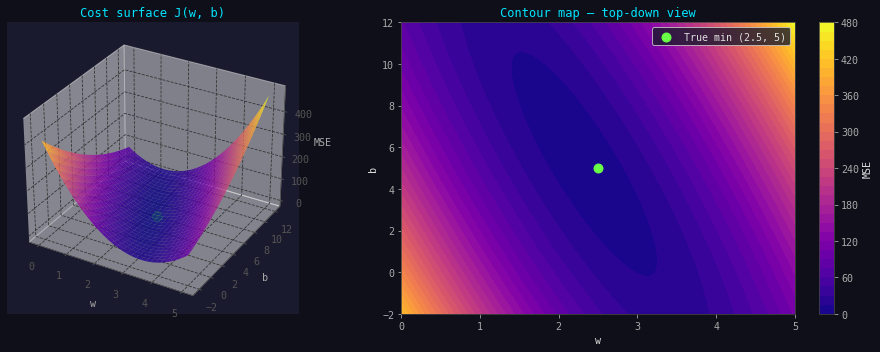

In [4]:
w_range = np.linspace(0, 5, 60)
b_range = np.linspace(-2, 12, 60)
W, B = np.meshgrid(w_range, b_range)
Z = np.array([[mse(y, predict(X, wi, bi)) for wi in w_range] for bi in b_range])

fig = plt.figure(figsize=(14, 5), facecolor='#0f0f1a')

# 3D bowl
ax3d = fig.add_subplot(121, projection='3d', facecolor='#1a1a2e')
surf = ax3d.plot_surface(W, B, Z, cmap='plasma', alpha=0.85, linewidth=0)
ax3d.scatter([2.5], [5], [mse(y, predict(X, 2.5, 5))],
             color=ACCENT3, s=100, zorder=10, label='True minimum')
ax3d.set_xlabel('w', color='#aaa'); ax3d.set_ylabel('b', color='#aaa')
ax3d.set_zlabel('MSE', color='#aaa')
ax3d.set_title('Cost surface J(w, b)', color=ACCENT)
ax3d.tick_params(colors='#555')

# Contour map
ax2d = fig.add_subplot(122)
cp = ax2d.contourf(W, B, Z, levels=40, cmap='plasma')
ax2d.scatter([2.5], [5], color=ACCENT3, s=80, zorder=5, label='True min (2.5, 5)')
ax2d.set_xlabel('w'); ax2d.set_ylabel('b')
ax2d.set_title('Contour map — top-down view', color=ACCENT)
ax2d.legend(); fig.colorbar(cp, ax=ax2d, label='MSE')

plt.tight_layout(); plt.show()

---
## Part 4 — Gradient Descent

We slide down the bowl by following the **negative gradient** — the steepest downhill direction.

The partial derivatives of MSE:

$$\frac{\partial J}{\partial w} = -\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - \hat{y}_i)$$

$$\frac{\partial J}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)$$

**Update rule** (repeat until convergence):
$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}, \quad b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

$\alpha$ is the **learning rate** — how big each step is.

In [5]:
class SimpleLinearRegression:
    """Simple Linear Regression via Gradient Descent — from scratch."""

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.w = 0.0          # slope
        self.b = 0.0          # intercept
        self.history = []     # track cost at each step
        self.wb_history = []  # track (w, b) trajectory

    def fit(self, X, y):
        n = len(X)
        for _ in range(self.n_iter):
            y_hat = self.w * X + self.b
            residuals = y - y_hat

            # Gradients — derived from ∂MSE/∂w and ∂MSE/∂b
            dw = (-2 / n) * np.dot(X, residuals)
            db = (-2 / n) * np.sum(residuals)

            # Simultaneous update
            self.w -= self.lr * dw
            self.b -= self.lr * db

            self.history.append(np.mean(residuals ** 2))
            self.wb_history.append((self.w, self.b))

        return self

    def predict(self, X):
        return self.w * X + self.b


# ── Train ────────────────────────────────────────────────────────────
model = SimpleLinearRegression(learning_rate=0.005, n_iterations=2000)
model.fit(X, y)

print(f'Learned  w = {model.w:.4f}  (true: 2.5)')
print(f'Learned  b = {model.b:.4f}  (true: 5.0)')
print(f'Final MSE  = {model.history[-1]:.4f}')

Learned  w = 2.3306  (true: 2.5)
Learned  b = 5.1628  (true: 5.0)
Final MSE  = 7.4265


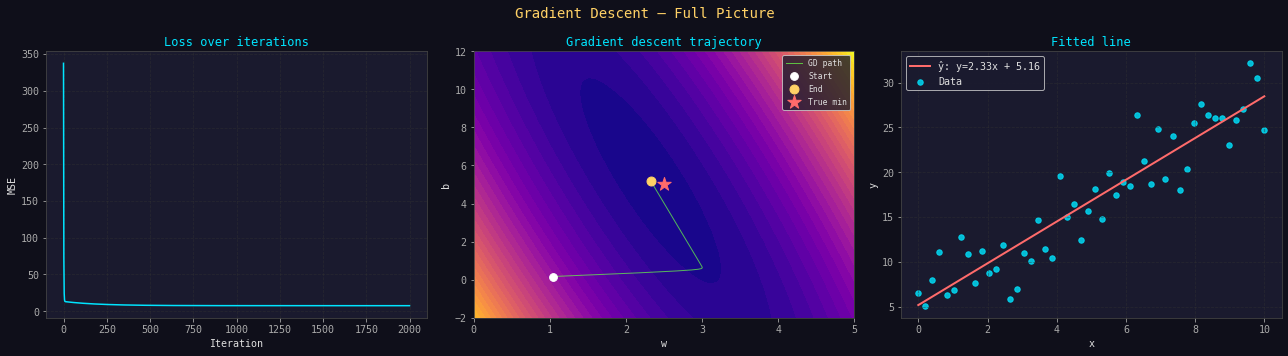

In [6]:
# ── Visualise training: loss curve + gradient path on contour ─────────
wb_arr = np.array(model.wb_history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 — Loss curve
axes[0].plot(model.history, color=ACCENT, lw=1.5)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MSE')
axes[0].set_title('Loss over iterations', color=ACCENT)
axes[0].grid(True)

# 2 — Gradient descent path on contour
cp = axes[1].contourf(W, B, Z, levels=40, cmap='plasma')
axes[1].plot(wb_arr[:, 0], wb_arr[:, 1], color=ACCENT3, lw=1, alpha=0.7, label='GD path')
axes[1].scatter(wb_arr[0, 0], wb_arr[0, 1], color='white', s=60, zorder=5, label='Start')
axes[1].scatter(wb_arr[-1, 0], wb_arr[-1, 1], color=GOLD, s=80, zorder=5, label='End')
axes[1].scatter([2.5], [5], color=ACCENT2, marker='*', s=200, zorder=6, label='True min')
axes[1].set_xlabel('w'); axes[1].set_ylabel('b')
axes[1].set_title('Gradient descent trajectory', color=ACCENT)
axes[1].legend(fontsize=8)

# 3 — Final fit
axes[2].scatter(X, y, color=ACCENT, s=30, alpha=0.8, label='Data')
axes[2].plot(X, model.predict(X), color=ACCENT2, lw=2, label=f'ŷ: y={model.w:.2f}x + {model.b:.2f}')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
axes[2].set_title('Fitted line', color=ACCENT)
axes[2].legend(); axes[2].grid(True)

plt.suptitle('Gradient Descent — Full Picture', color=GOLD, fontsize=14)
plt.tight_layout(); plt.show()

---
## Part 5 — Effect of Learning Rate

The learning rate $\alpha$ controls step size:
- **Too small** → learns, but very slowly
- **Too large** → overshoots, diverges
- **Just right** → converges efficiently

C:\Users\pc\AppData\Roaming\Python\Python39\site-packages\numpy\core\_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\pc\AppData\Local\Temp/ipykernel_33180/3107312112.py:26: RuntimeWarning: overflow encountered in square
  self.history.append(np.mean(residuals ** 2))
C:\Users\pc\AppData\Local\Temp/ipykernel_33180/3107312112.py:15: RuntimeWarning: invalid value encountered in multiply
  y_hat = self.w * X + self.b


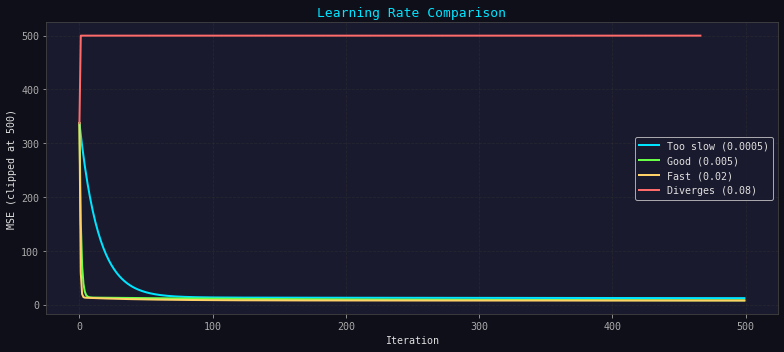

In [7]:
lrs = [0.0005, 0.005, 0.02, 0.08]
colors = [ACCENT, ACCENT3, GOLD, ACCENT2]
labels = ['Too slow (0.0005)', 'Good (0.005)', 'Fast (0.02)', 'Diverges (0.08)']

fig, ax = plt.subplots(figsize=(11, 5))
for lr, col, lbl in zip(lrs, colors, labels):
    m = SimpleLinearRegression(learning_rate=lr, n_iterations=500)
    m.fit(X, y)
    h = np.clip(m.history, 0, 500)      # clip diverging runs for readability
    ax.plot(h, color=col, lw=2, label=lbl)

ax.set_xlabel('Iteration'); ax.set_ylabel('MSE (clipped at 500)')
ax.set_title('Learning Rate Comparison', color=ACCENT, fontsize=13)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Part 6 — The Normal Equation (Closed-Form Solution)

Instead of iterating, we can solve for the **exact optimum** in one shot using calculus.

In matrix form, the model is:
$$\hat{\mathbf{y}} = \mathbf{X} \boldsymbol{\theta}$$

Setting the gradient to zero and solving:
$$\boldsymbol{\theta}^* = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

> **When to use?**  
> ✅ Small/medium datasets (< ~10k features) — exact and fast  
> ❌ Very large datasets — matrix inversion is $O(n^3)$, use GD instead

In [8]:
def normal_equation(X, y):
    """
    θ* = (XᵀX)⁻¹ Xᵀy
    X must already include a bias column of 1s.
    """
    return np.linalg.inv(X.T @ X) @ X.T @ y


# Add bias column (column of 1s)
X_b = np.column_stack([np.ones(len(X)), X])   # shape (n, 2)
theta = normal_equation(X_b, y)
b_ne, w_ne = theta

print(f'Normal Equation → w = {w_ne:.6f}, b = {b_ne:.6f}')
print(f'Gradient Descent → w = {model.w:.6f}, b = {model.b:.6f}')
print(f'True values      → w = 2.500000, b = 5.000000')

# --- Walk through the matrix algebra step by step ---
print('\n── Step-by-step breakdown ──')
XtX = X_b.T @ X_b
XtX_inv = np.linalg.inv(XtX)
Xty = X_b.T @ y
print(f'XᵀX  =\n{XtX.round(1)}')
print(f'(XᵀX)⁻¹ @ Xᵀy  = {(XtX_inv @ Xty).round(4)}')

Normal Equation → w = 2.326050, b = 5.193329
Gradient Descent → w = 2.330613, b = 5.162830
True values      → w = 2.500000, b = 5.000000

── Step-by-step breakdown ──
XᵀX  =
[[  50.   250. ]
 [ 250.  1683.7]]
(XᵀX)⁻¹ @ Xᵀy  = [5.1933 2.326 ]


---
## Part 7 — Multiple Linear Regression

Now we have **multiple features** $x_1, x_2, \ldots, x_p$:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_p x_p + b$$

In matrix notation (much cleaner!):
$$\hat{\mathbf{y}} = \mathbf{X} \boldsymbol{\theta}, \quad \boldsymbol{\theta} = [b, w_1, w_2, \ldots, w_p]^T$$

The math is **identical** to simple linear regression — just replace scalars with vectors/matrices.

In [9]:
class MultipleLinearRegression:
    """Multiple Linear Regression — Gradient Descent, vectorised."""

    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.theta = None       # [b, w1, w2, ...]
        self.history = []

    def _add_bias(self, X):
        return np.column_stack([np.ones(X.shape[0]), X])

    def fit(self, X, y):
        Xb = self._add_bias(X)          # (n, p+1)
        n, p = Xb.shape
        self.theta = np.zeros(p)        # initialise weights at 0

        for _ in range(self.n_iter):
            y_hat = Xb @ self.theta
            residuals = y - y_hat
            grad = (-2 / n) * Xb.T @ residuals   # vectorised gradient
            self.theta -= self.lr * grad
            self.history.append(np.mean(residuals ** 2))

        return self

    def predict(self, X):
        return self._add_bias(X) @ self.theta

    @property
    def coef_(self):
        return self.theta[1:]   # weights (slopes)

    @property
    def intercept_(self):
        return self.theta[0]    # bias


print('MultipleLinearRegression class defined ✓')

MultipleLinearRegression class defined ✓


In [10]:
# ── Synthetic 2-feature dataset ────────────────────────────────────
# House price example:
#   y = 50*size + 30*bedrooms + 10 + noise

n2 = 200
size     = np.random.uniform(30, 150, n2)    # house size in m²
bedrooms = np.random.randint(1, 6, n2).astype(float)
noise    = np.random.randn(n2) * 15

price = 50 * size + 30 * bedrooms + 10 + noise

X2 = np.column_stack([size, bedrooms])

# ── Feature scaling — critical for GD convergence ──────────────────
# Without scaling, features with large ranges dominate the gradient.
X2_mean = X2.mean(axis=0)
X2_std  = X2.std(axis=0)
X2_scaled = (X2 - X2_mean) / X2_std

mlr = MultipleLinearRegression(lr=0.05, n_iter=1000)
mlr.fit(X2_scaled, price)

print('True coefficients:   w1=50 (size), w2=30 (bedrooms), b=10')
print(f'Learned intercept:   {mlr.intercept_:.2f}')
print(f'Learned coefs (scaled): {mlr.coef_}')
print(f'Final MSE: {mlr.history[-1]:.2f}')

True coefficients:   w1=50 (size), w2=30 (bedrooms), b=10
Learned intercept:   4619.93
Learned coefs (scaled): [1775.83703326   42.27692517]
Final MSE: 231.45


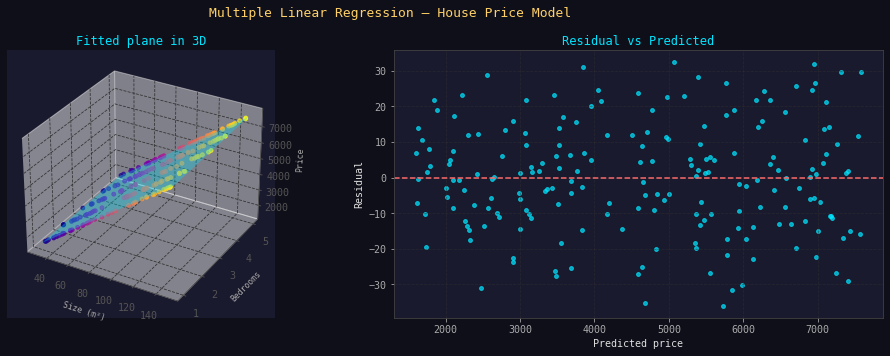

In [11]:
# ── 3-D scatter + fitted plane ────────────────────────────────────
fig = plt.figure(figsize=(14, 5), facecolor='#0f0f1a')

ax3 = fig.add_subplot(121, projection='3d', facecolor='#1a1a2e')
sc  = ax3.scatter(size, bedrooms, price, c=price, cmap='plasma', s=15, alpha=0.7)

# Fitted plane
s_grid = np.linspace(30, 150, 20)
b_grid = np.linspace(1, 5, 20)
S, BE  = np.meshgrid(s_grid, b_grid)
Xplane = np.column_stack([S.ravel(), BE.ravel()])
Xplane_sc = (Xplane - X2_mean) / X2_std
Pplane = mlr.predict(Xplane_sc).reshape(S.shape)

ax3.plot_surface(S, BE, Pplane, alpha=0.35, color=ACCENT, linewidth=0)
ax3.set_xlabel('Size (m²)', color='#aaa', fontsize=8)
ax3.set_ylabel('Bedrooms', color='#aaa', fontsize=8)
ax3.set_zlabel('Price', color='#aaa', fontsize=8)
ax3.set_title('Fitted plane in 3D', color=ACCENT)
ax3.tick_params(colors='#555')

# Residual plot
ax2 = fig.add_subplot(122)
y_pred_mlr = mlr.predict(X2_scaled)
ax2.scatter(y_pred_mlr, price - y_pred_mlr, color=ACCENT, s=15, alpha=0.7)
ax2.axhline(0, color=ACCENT2, lw=1.5, linestyle='--')
ax2.set_xlabel('Predicted price'); ax2.set_ylabel('Residual')
ax2.set_title('Residual vs Predicted', color=ACCENT)
ax2.grid(True)

plt.suptitle('Multiple Linear Regression — House Price Model', color=GOLD, fontsize=13)
plt.tight_layout(); plt.show()

---
## Part 8 — Evaluation Metrics

| Metric | Formula | Meaning |
|--------|---------|--------|
| MSE | $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$ | Average squared error |
| RMSE | $\sqrt{\text{MSE}}$ | Same units as y |
| MAE | $\frac{1}{n}\sum |y_i - \hat{y}_i|$ | Average absolute error |
| R² | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained |

$R^2 = 1$ is a perfect fit. $R^2 = 0$ means your model does no better than predicting the mean.


{
Metric    Simple LR (size only)  Multiple LR (size+beds)
--------------------------------------------------------
MSE                   2007.0212                 231.4451
RMSE                    44.7998                  15.2133
MAE                     38.5686                  12.3387
R²                       0.9994                   0.9999


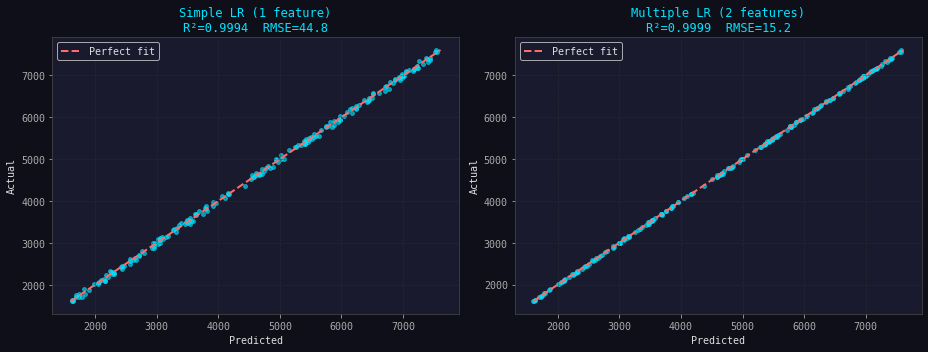

In [13]:
def compute_metrics(y_true, y_pred):
    n = len(y_true)
    residuals = y_true - y_pred

    mse_val  = np.mean(residuals ** 2)
    rmse_val = np.sqrt(mse_val)
    mae_val  = np.mean(np.abs(residuals))

    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2_val = 1 - ss_res / ss_tot

    return {'MSE': mse_val, 'RMSE': rmse_val, 'MAE': mae_val, 'R²': r2_val}


# ── Compare Simple vs Multiple LR ───────────────────────────────────
# Re-train simple LR on the house dataset (size only)
size_scaled = (size - size.mean()) / size.std()
slr = SimpleLinearRegression(learning_rate=0.05, n_iterations=1000)
slr.fit(size_scaled, price)

metrics_simple   = compute_metrics(price, slr.predict(size_scaled))
metrics_multiple = compute_metrics(price, mlr.predict(X2_scaled))

print('\n{')
print(f'{"Metric":<8} {"Simple LR (size only)":>22} {"Multiple LR (size+beds)":>24}')
print('-' * 56)
for k in ['MSE', 'RMSE', 'MAE', 'R²']:
    print(f'{k:<8} {metrics_simple[k]:>22.4f} {metrics_multiple[k]:>24.4f}')

# ── Visual R² intuition ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title, metrics in [
    (axes[0], slr.predict(size_scaled), 'Simple LR (1 feature)', metrics_simple),
    (axes[1], mlr.predict(X2_scaled),   'Multiple LR (2 features)', metrics_multiple)
]:
    ax.scatter(preds, price, color=ACCENT, s=15, alpha=0.6)
    mn, mx = min(preds.min(), price.min()), max(preds.max(), price.max())
    ax.plot([mn, mx], [mn, mx], color=ACCENT2, lw=2, linestyle='--', label='Perfect fit')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{title}\nR²={metrics["R²"]:.4f}  RMSE={metrics["RMSE"]:.1f}', color=ACCENT)
    ax.legend(); ax.grid(True)

plt.tight_layout(); plt.show()

---
## Part 9 — Model Assumptions & Diagnostics

Linear regression relies on 4 key assumptions (LINE):
1. **L**inearity — the relationship between X and y is linear
2. **I**ndependence — observations are independent
3. **N**ormality — residuals are normally distributed
4. **E**qual variance (Homoscedasticity) — residuals have constant variance

These are checked with **diagnostic plots**.

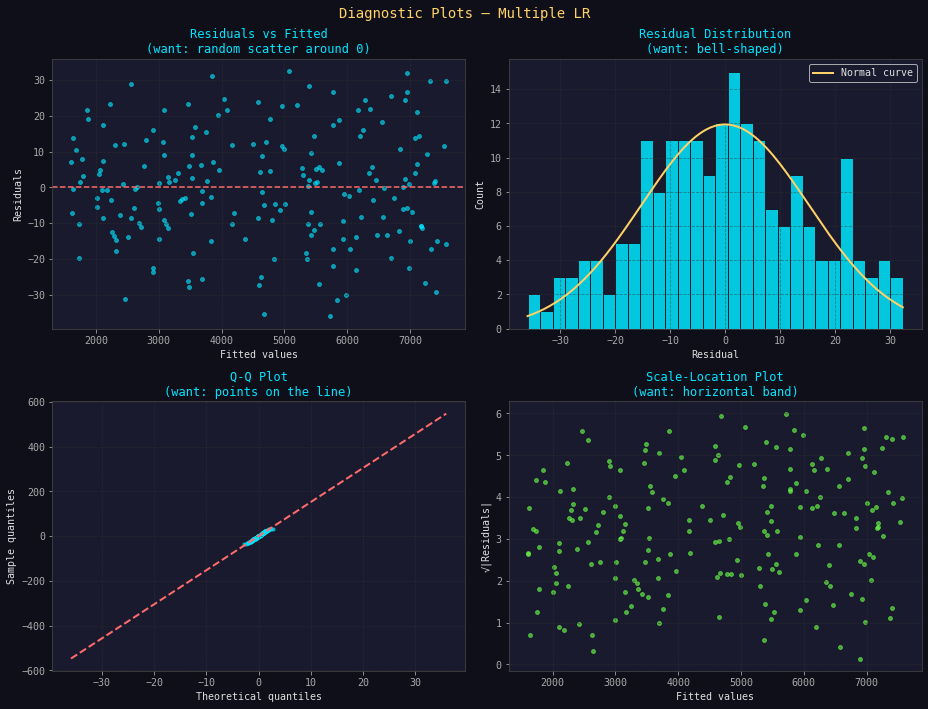

In [14]:
y_pred_final = mlr.predict(X2_scaled)
res = price - y_pred_final

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1 — Residuals vs Fitted (check linearity & homoscedasticity)
axes[0, 0].scatter(y_pred_final, res, color=ACCENT, s=15, alpha=0.6)
axes[0, 0].axhline(0, color=ACCENT2, lw=1.5, linestyle='--')
axes[0, 0].set_xlabel('Fitted values'); axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted\n(want: random scatter around 0)', color=ACCENT)
axes[0, 0].grid(True)

# 2 — Histogram of residuals (check normality)
axes[0, 1].hist(res, bins=30, color=ACCENT, edgecolor='#0f0f1a', alpha=0.85)
# Overlay normal curve
mu, sigma = res.mean(), res.std()
x_norm = np.linspace(res.min(), res.max(), 200)
norm_curve = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_norm-mu)/sigma)**2)
norm_curve *= len(res) * (res.max()-res.min()) / 30
axes[0, 1].plot(x_norm, norm_curve, color=GOLD, lw=2, label='Normal curve')
axes[0, 1].set_xlabel('Residual'); axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Residual Distribution\n(want: bell-shaped)', color=ACCENT)
axes[0, 1].legend(); axes[0, 1].grid(True)

# 3 — Q-Q plot (normality)
sorted_res = np.sort(res)
n_pts = len(sorted_res)
theoretical_q = np.array([np.percentile(np.random.randn(10000), 100*(i+0.5)/n_pts)
                           for i in range(n_pts)])
axes[1, 0].scatter(theoretical_q, sorted_res, color=ACCENT, s=10, alpha=0.6)
lim = max(abs(theoretical_q).max(), abs(sorted_res).max())
axes[1, 0].plot([-lim, lim], [-lim*sigma+mu, lim*sigma+mu], color=ACCENT2, lw=2, linestyle='--')
axes[1, 0].set_xlabel('Theoretical quantiles'); axes[1, 0].set_ylabel('Sample quantiles')
axes[1, 0].set_title('Q-Q Plot\n(want: points on the line)', color=ACCENT)
axes[1, 0].grid(True)

# 4 — Scale-Location (homoscedasticity)
sqrt_abs_res = np.sqrt(np.abs(res))
axes[1, 1].scatter(y_pred_final, sqrt_abs_res, color=ACCENT3, s=15, alpha=0.6)
axes[1, 1].set_xlabel('Fitted values'); axes[1, 1].set_ylabel('√|Residuals|')
axes[1, 1].set_title('Scale-Location Plot\n(want: horizontal band)', color=ACCENT)
axes[1, 1].grid(True)

plt.suptitle('Diagnostic Plots — Multiple LR', color=GOLD, fontsize=14)
plt.tight_layout(); plt.show()

---
## Part 10 — Normal Equation vs Gradient Descent

A side-by-side comparison of both solution methods.

                                Normal Equation Gradient Descent
----------------------------------------------------------------
Intercept (b)                         4619.9310        4619.9310
Weight w1 (size)                      1775.8370        1775.8370
Weight w2 (bedrooms)                    42.2769          42.2769
R²                                     0.999927         0.999927
RMSE                                    15.2133          15.2133


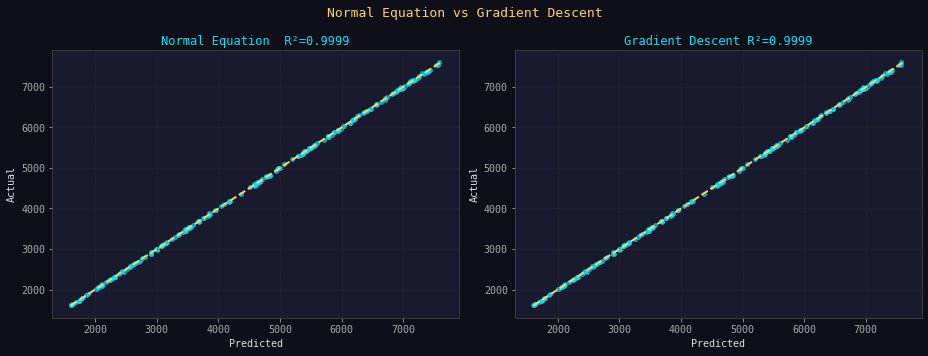

In [15]:
# Normal equation on the multi-feature dataset
Xb_multi = np.column_stack([np.ones(n2), X2_scaled])
theta_ne  = normal_equation(Xb_multi, price)

y_ne  = Xb_multi @ theta_ne
y_gd  = mlr.predict(X2_scaled)

m_ne  = compute_metrics(price, y_ne)
m_gd  = compute_metrics(price, y_gd)

print(f'{"":30} {"Normal Equation":>16} {"Gradient Descent":>16}')
print('-' * 64)
print(f'{"Intercept (b)":<30} {theta_ne[0]:>16.4f} {mlr.intercept_:>16.4f}')
print(f'{"Weight w1 (size)":<30} {theta_ne[1]:>16.4f} {mlr.coef_[0]:>16.4f}')
print(f'{"Weight w2 (bedrooms)":<30} {theta_ne[2]:>16.4f} {mlr.coef_[1]:>16.4f}')
print(f'{"R²":<30} {m_ne["R²"]:>16.6f} {m_gd["R²"]:>16.6f}')
print(f'{"RMSE":<30} {m_ne["RMSE"]:>16.4f} {m_gd["RMSE"]:>16.4f}')

# ── Comparison: predicted vs actual ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title in [
    (axes[0], y_ne, f'Normal Equation  R²={m_ne["R²"]:.4f}'),
    (axes[1], y_gd, f'Gradient Descent R²={m_gd["R²"]:.4f}')
]:
    ax.scatter(preds, price, color=ACCENT, s=15, alpha=0.6)
    mn, mx = min(preds.min(), price.min()), max(preds.max(), price.max())
    ax.plot([mn, mx], [mn, mx], color=GOLD, lw=2, linestyle='--')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title, color=ACCENT)
    ax.grid(True)

plt.suptitle('Normal Equation vs Gradient Descent', color=GOLD, fontsize=13)
plt.tight_layout(); plt.show()

---
## Part 11 — Polynomial Features (Going Non-Linear with Linear Regression)

Linear regression can fit **curves** by creating polynomial features manually.

$$\hat{y} = w_1 x + w_2 x^2 + w_3 x^3 + b$$

This is still *linear regression* — linear in the **parameters** $w_i$.

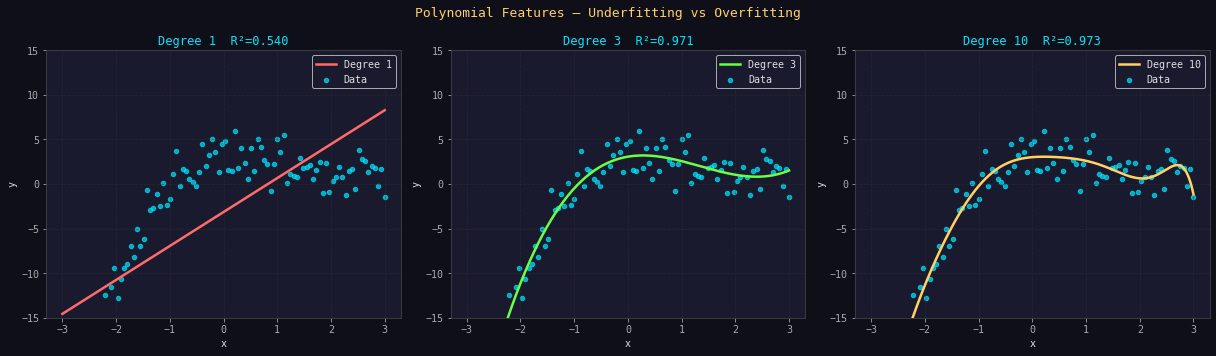

Degree 1 = underfitting | Degree 3 = good fit | Degree 10 = overfitting


In [16]:
# ── Curved data ──────────────────────────────────────────────────────
x_p = np.linspace(-3, 3, 100)
y_p = 0.5 * x_p**3 - 2 * x_p**2 + x_p + 3 + np.random.randn(100) * 1.5

def poly_features(x, degree):
    """Build [1, x, x², x³, ...] matrix."""
    return np.column_stack([x**i for i in range(degree + 1)])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x_plot = np.linspace(-3, 3, 300)
degrees = [1, 3, 10]
colors  = [ACCENT2, ACCENT3, GOLD]

for ax, deg, col in zip(axes, degrees, colors):
    Xpoly = poly_features(x_p, deg)
    theta_p = normal_equation(Xpoly, y_p)
    y_plot  = poly_features(x_plot, deg) @ theta_p

    ax.scatter(x_p, y_p, color=ACCENT, s=20, alpha=0.7, label='Data')
    ax.plot(x_plot, y_plot, color=col, lw=2.5, label=f'Degree {deg}')

    m = compute_metrics(y_p, Xpoly @ theta_p)
    ax.set_title(f'Degree {deg}  R²={m["R²"]:.3f}', color=ACCENT)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(); ax.grid(True)
    ax.set_ylim(-15, 15)

plt.suptitle('Polynomial Features — Underfitting vs Overfitting', color=GOLD, fontsize=13)
plt.tight_layout(); plt.show()
print('Degree 1 = underfitting | Degree 3 = good fit | Degree 10 = overfitting')

---
## Part 12 — Summary Card

```
┌─────────────────────────────────────────────────────────────────┐
│                  LINEAR REGRESSION — CHEAT SHEET                │
├──────────────────────┬──────────────────────────────────────────┤
│ Model                │ ŷ = Xθ  (X includes bias column)        │
│ Cost                 │ J = (1/n) Σ (y - ŷ)²                   │
│ Gradient (w)         │ ∂J/∂θ = (-2/n) Xᵀ(y - ŷ)              │
│ Update               │ θ ← θ - α ∂J/∂θ                        │
│ Normal Equation      │ θ* = (XᵀX)⁻¹ Xᵀy                      │
├──────────────────────┼──────────────────────────────────────────┤
│ GD: use when         │ Many features (p > 10k), large datasets │
│ NE: use when         │ Small/medium p, need exact solution     │
├──────────────────────┼──────────────────────────────────────────┤
│ Always scale         │ (x - mean) / std before GD             │
│ Tune learning rate   │ Plot loss curve; try 0.001 → 0.1       │
│ Check residuals      │ Should be random, mean ≈ 0             │
└──────────────────────┴──────────────────────────────────────────┘
```

In [ ]:
print('''
╔══════════════════════════════════════════════════════════════════╗
║           Notebook complete! What you built from scratch:        ║
╠══════════════════════════════════════════════════════════════════╣
║  ✅ MSE cost function                                            ║
║  ✅ Gradient Descent (simple & vectorised)                       ║
║  ✅ Normal Equation (closed-form)                                ║
║  ✅ Multiple Linear Regression (matrix form)                     ║
║  ✅ Feature scaling (standardisation)                            ║
║  ✅ Evaluation metrics: MSE, RMSE, MAE, R²                       ║
║  ✅ Diagnostic plots (residuals, Q-Q, scale-location)            ║
║  ✅ Polynomial features & the bias-variance tradeoff             ║
╚══════════════════════════════════════════════════════════════════╝
''')